In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import itertools
from pathlib import Path
from typing import Any, TypeVar
import re

import h5py
import matplotlib.pyplot as plt
import mne
import numpy as np
import pandas as pd
from scipy.stats import ttest_ind
import seaborn as sns
from tqdm.auto import tqdm

In [3]:
from src.data import add_metadata_features
from src.viz import plot_epochs, add_timit_insets, add_pod_line, add_uv_annotation

In [4]:
all_epoch_paths = list(Path("outputs/epochs_preprocessed").glob("*_epo.fif"))

In [5]:
epochs = {}
for path in tqdm(all_epoch_paths):
    subject_name = re.findall("(EC[\d]+)_epo", str(path))[0]
    epochs[subject_name] = mne.read_epochs(str(path), verbose=False)
    try:
        epochs[subject_name].metadata = add_metadata_features(epochs[subject_name].metadata)
    except AssertionError:
        del epochs[subject_name]
        continue

  0%|          | 0/10 [00:00<?, ?it/s]

Replacing existing metadata with 83 columns
Replacing existing metadata with 82 columns
Replacing existing metadata with 82 columns
Replacing existing metadata with 83 columns
Replacing existing metadata with 83 columns
Replacing existing metadata with 83 columns
Replacing existing metadata with 82 columns
Replacing existing metadata with 83 columns
Replacing existing metadata with 83 columns
Replacing existing metadata with 82 columns


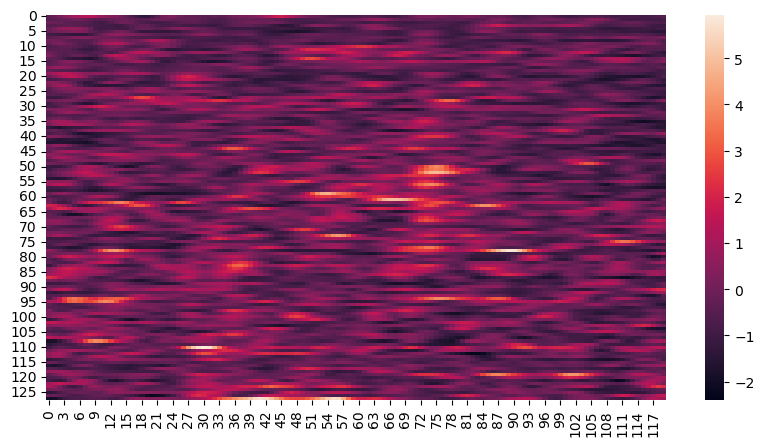

In [24]:
plot_channels = np.arange(128)

f, ax = plt.subplots(1, 1, figsize=(10, 5))
# for line in epochs["EC248"][0].get_data()[0, plot_channels, :]:
    # ax.plot(line)
sns.heatmap(epochs["EC248"][0].get_data()[0, plot_channels, :], ax=ax)
plt.show()

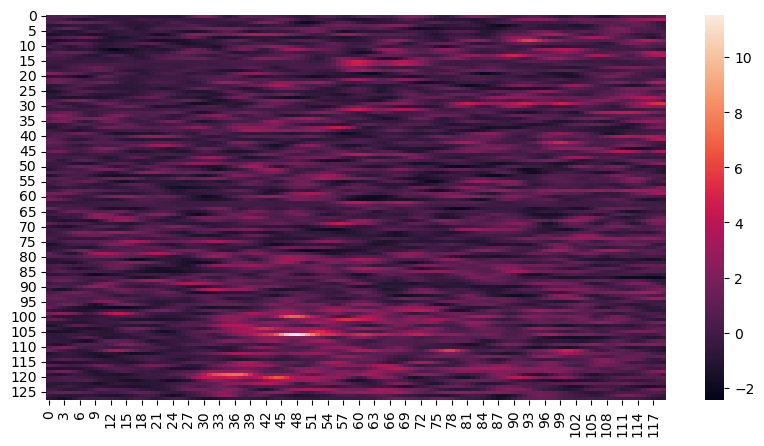

In [26]:
plot_channels = np.arange(128)

f, ax = plt.subplots(1, 1, figsize=(10, 5))
# for line in epochs["EC282"][0].get_data()[0, plot_channels, :]:
#     ax.plot(line)
sns.heatmap(epochs["EC282"][0].get_data()[0, plot_channels, :], ax=ax)
plt.show()